# No-chem interaction plots

Recreates the 5 insight / interaction plots from `run_no_chem_analysis.py` using the user-specified CSVs:
- LT2Y: `../hypothesis-testing/_no_chem_data/less_than-2yrs-nochem.csv`
- GT2Y: `../hypothesis-testing/_no_chem_data/more_than-2yrs_monthly-nochem.csv`

Adapted to the schema in these files (`calendar_year` + `calendar_month` instead of `year_month`; no `primary_carwash_type`; `client_type` only on LT2Y, so multi/single is derived from chain size for GT2Y / combined panel).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110

LT_PATH = '../hypothesis-testing/_no_chem_data/less_than-2yrs-nochem.csv'
GT_PATH = '../hypothesis-testing/_no_chem_data/more_than-2yrs_monthly-nochem.csv'

## Load + derive `year_month_dt` + apply data-hygiene filters

Two filters applied at load (matching the modeling notebook to roughly halve the noise):
1. Drop partial-launch months: rows where `operational_start_date.day > 15` AND `msl == 0`.
2. Drop operational anomalies / soft-opens: rows where `wash_count_total < 500`.

In [2]:
def load(path):
    df = pd.read_csv(path, low_memory=False)
    df['year_month_dt'] = pd.to_datetime(
        df['calendar_year'].astype(str) + '-' + df['calendar_month'].astype(str).str.zfill(2) + '-01',
        errors='coerce',
    )
    df = df[(df['year_month_dt'] >= '2024-01-01') & (df['year_month_dt'] <= '2025-12-01')].copy()

    # ---- Data hygiene filters (match modeling notebook) ----
    before = len(df)
    df['op_date'] = pd.to_datetime(df['operational_start_date'], errors='coerce')
    df['msl'] = (
        (df['year_month_dt'].dt.year - df['op_date'].dt.year) * 12
        + (df['year_month_dt'].dt.month - df['op_date'].dt.month)
    )
    df['op_day'] = df['op_date'].dt.day
    # 1. drop partial-launch month (mid-month opening, msl=0)
    mask_partial = (df['msl'] == 0) & (df['op_day'] > 15)
    df = df[~mask_partial].copy()
    # 2. drop operational anomalies / soft-opens
    df = df[df['wash_count_total'] >= 500].copy()
    after = len(df)
    print(f'  filtered {before:,} -> {after:,} rows  ({before-after:,} dropped)')
    return df

print('LT2Y (new):')
new = load(LT_PATH)
print('GT2Y (old):')
old = load(GT_PATH)

print(f'\nLT2Y: {new.shape[0]:,} rows  |  {new["client_id_location_id"].nunique():,} sites')
print(f'GT2Y: {old.shape[0]:,} rows  |  {old["client_id_location_id"].nunique():,} sites')

LT2Y (new):
  filtered 4,047 -> 3,881 rows  (166 dropped)
GT2Y (old):
  filtered 11,548 -> 11,360 rows  (188 dropped)

LT2Y: 3,881 rows  |  221 sites
GT2Y: 11,360 rows  |  479 sites


In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dlat = p2 - p1
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

## Plot 1 — Age lifecycle cliff

Median YoY 2024→2025 wash-count growth, by `age_on_30_sep_25` bucket. The cliff at age 4–5 is the headline. Computed on GT2Y (the only cohort with both years).

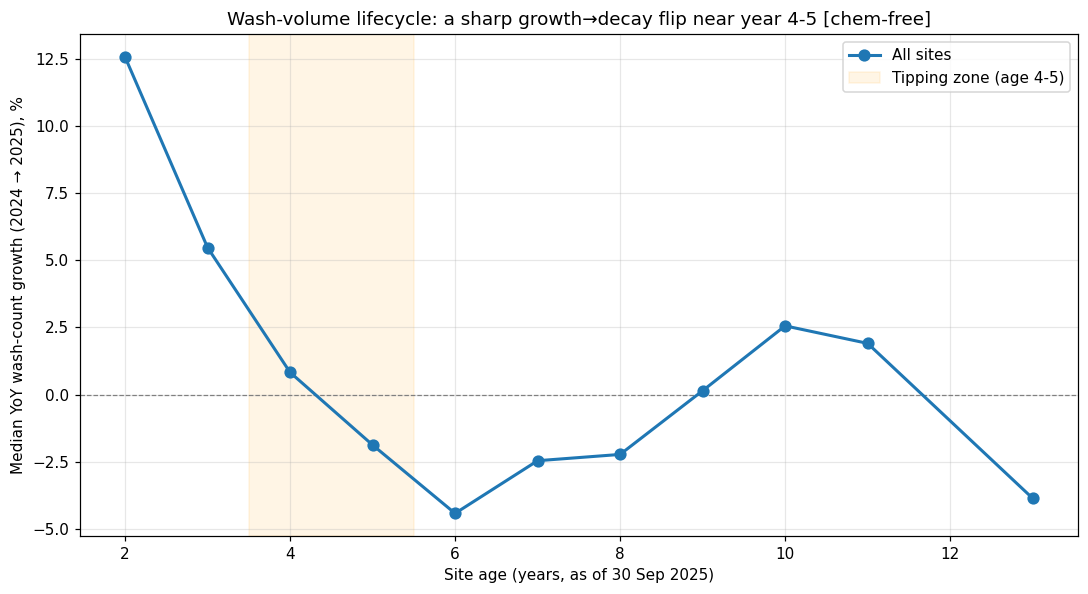

In [4]:
ann = (
    old.groupby(['client_id_location_id', 'age_on_30_sep_25', old['year_month_dt'].dt.year])['wash_count_total']
    .mean()
    .unstack(level=2)
)
ann.columns = ['a2024', 'a2025']
ann = ann.reset_index()
ann['yoy'] = (ann['a2025'] / ann['a2024'] - 1) * 100

counts = ann.groupby('age_on_30_sep_25').size()
age_pts = ann.groupby('age_on_30_sep_25')['yoy'].median().reset_index()
age_pts = age_pts[age_pts['age_on_30_sep_25'].map(counts) >= 5]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.plot(age_pts['age_on_30_sep_25'], age_pts['yoy'], 'o-', color='#1f77b4', lw=2, ms=7, label='All sites')
ax.axvspan(3.5, 5.5, color='orange', alpha=0.10, label='Tipping zone (age 4-5)')
ax.set_xlabel('Site age (years, as of 30 Sep 2025)')
ax.set_ylabel('Median YoY wash-count growth (2024 → 2025), %')
ax.set_title('Wash-volume lifecycle: a sharp growth→decay flip near year 4-5 [chem-free]')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Plot 2 — Membership share as Q1-2024 leading indicator

Sites bucketed into deciles of their Q1-2024 membership share. Left: median 2024 monthly volume by decile. Right: median YoY growth 2024→2025 by decile. (GT2Y only.)

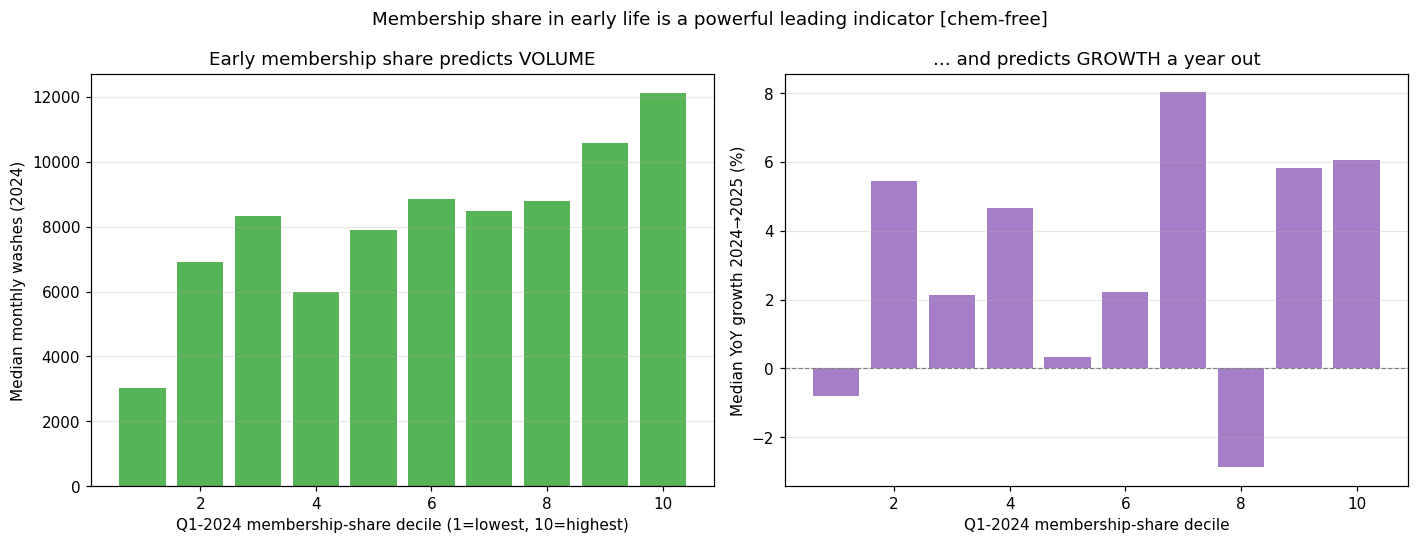

In [5]:
od = old.copy()
od['m_share'] = od['wash_count_membership'] / od['wash_count_total'].replace(0, np.nan)
early = (
    od[od['year_month_dt'] <= '2024-03-01']
    .groupby('client_id_location_id')['m_share']
    .mean()
    .rename('m_q1')
)
ann2 = od.groupby(['client_id_location_id', od['year_month_dt'].dt.year])['wash_count_total'].mean().unstack()
ann2.columns = ['a2024', 'a2025']
ann2['yoy'] = (ann2['a2025'] / ann2['a2024'] - 1) * 100
df = ann2.join(early).dropna()
df['decile'] = pd.qcut(df['m_q1'], 10, labels=False, duplicates='drop') + 1
gb = df.groupby('decile').agg(vol=('a2024', 'median'), yoy=('yoy', 'median')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(gb['decile'], gb['vol'], color='#2ca02c', alpha=0.8)
axes[0].set_xlabel('Q1-2024 membership-share decile (1=lowest, 10=highest)')
axes[0].set_ylabel('Median monthly washes (2024)')
axes[0].set_title('Early membership share predicts VOLUME')
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(gb['decile'], gb['yoy'], color='#9467bd', alpha=0.85)
axes[1].axhline(0, color='gray', lw=0.8, ls='--')
axes[1].set_xlabel('Q1-2024 membership-share decile')
axes[1].set_ylabel('Median YoY growth 2024→2025 (%)')
axes[1].set_title('... and predicts GROWTH a year out')
axes[1].grid(alpha=0.3, axis='y')

fig.suptitle('Membership share in early life is a powerful leading indicator [chem-free]', fontsize=12)
fig.tight_layout()
plt.show()

## Plot 3 — New-site ramp: multi-site vs single-site

LT2Y sites, first 12 months since opening. Left: median total washes per month. Right: median membership share.

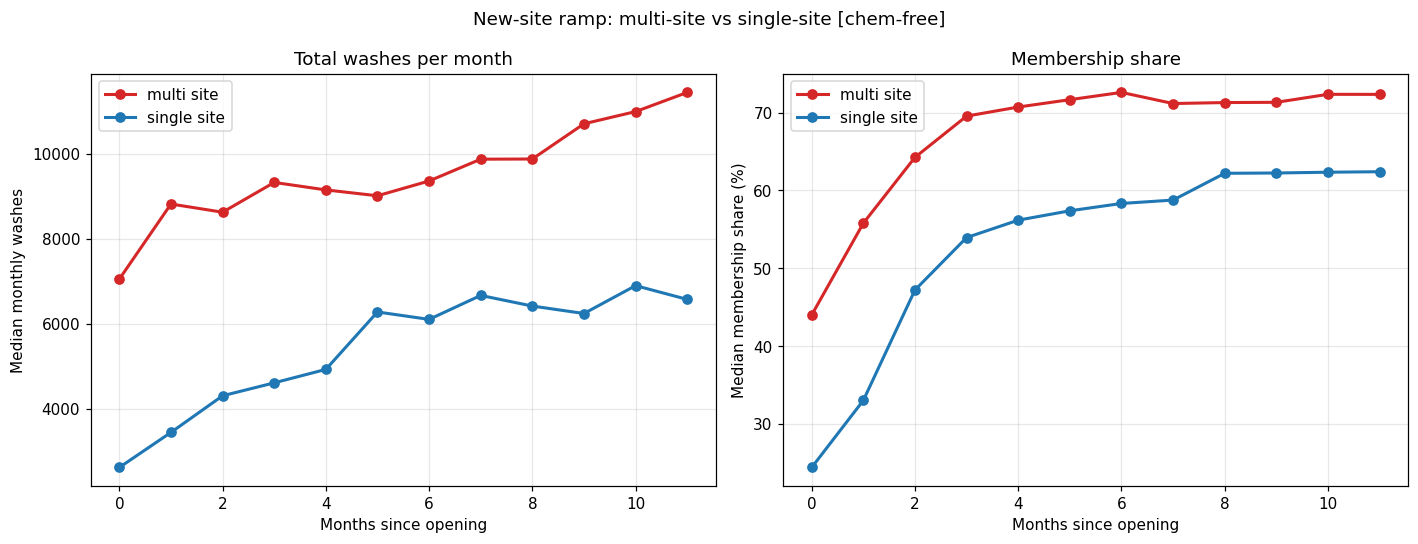

In [6]:
sub = new[new['operational_start_date'].notna()].copy()
sub['op'] = pd.to_datetime(sub['operational_start_date'])
sub['mso'] = (
    (sub['year_month_dt'].dt.year - sub['op'].dt.year) * 12
    + (sub['year_month_dt'].dt.month - sub['op'].dt.month)
)
sub = sub[(sub['mso'] >= 0) & (sub['mso'] <= 11)].copy()
sub['m_share'] = sub['wash_count_membership'] / sub['wash_count_total'].replace(0, np.nan)

ramp = sub.groupby(['client_type', 'mso']).agg(
    total=('wash_count_total', 'median'),
    m_share=('m_share', 'median'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ct, color in [('multi_site', '#d62728'), ('single_site', '#1f77b4')]:
    s = ramp[ramp['client_type'] == ct]
    axes[0].plot(s['mso'], s['total'], 'o-', label=ct.replace('_', ' '), color=color, lw=2)
    axes[1].plot(s['mso'], s['m_share'] * 100, 'o-', label=ct.replace('_', ' '), color=color, lw=2)

axes[0].set_xlabel('Months since opening'); axes[0].set_ylabel('Median monthly washes')
axes[0].set_title('Total washes per month'); axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].set_xlabel('Months since opening'); axes[1].set_ylabel('Median membership share (%)')
axes[1].set_title('Membership share'); axes[1].grid(alpha=0.3); axes[1].legend()
fig.suptitle('New-site ramp: multi-site vs single-site [chem-free]', fontsize=12)
fig.tight_layout()
plt.show()

## Plot 4 — Cannibalization donut

Each old (GT2Y) site is tagged with its distance to the **nearest** new (LT2Y) entrant. Left: median 2024→2025 YoY growth by distance bin. Right: share of old sites that declined. Peak damage tends to sit at 2–5 km.

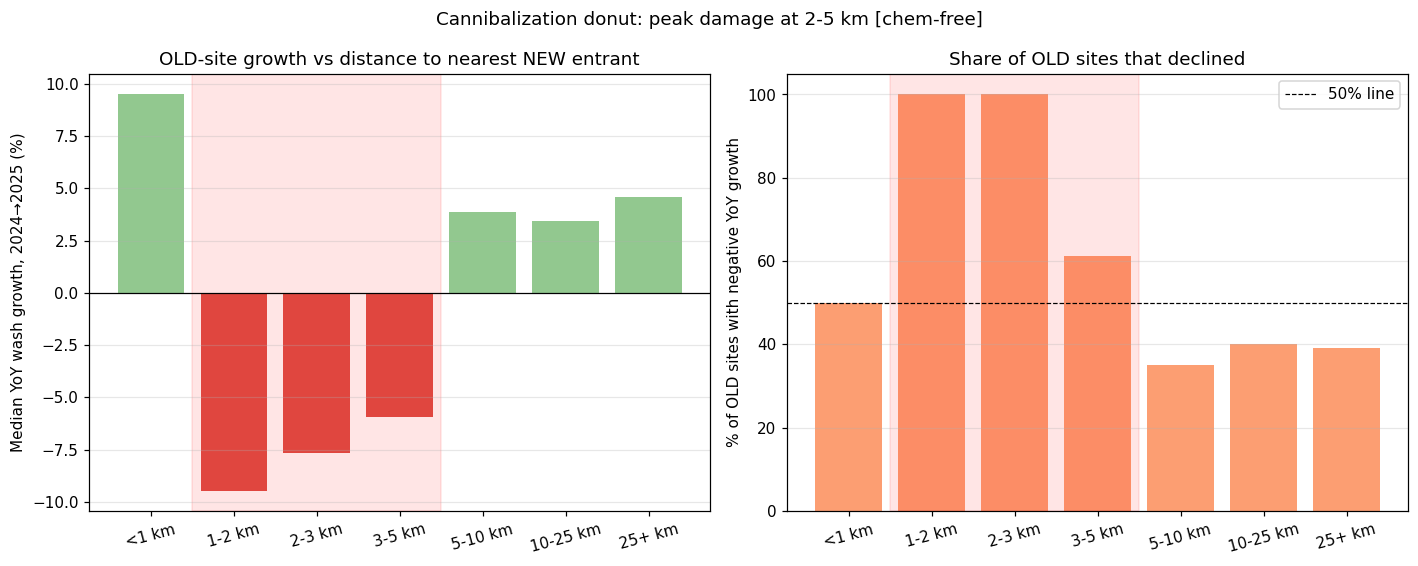

In [7]:
old_sites = old[['client_id_location_id', 'latitude', 'longitude']].dropna().drop_duplicates()
new_sites = new[['client_id_location_id', 'latitude', 'longitude']].dropna().drop_duplicates()
oa = old_sites[['latitude', 'longitude']].values
na = new_sites[['latitude', 'longitude']].values
min_dist = [haversine_km(oa[i, 0], oa[i, 1], na[:, 0], na[:, 1]).min() for i in range(len(oa))]
old_sites = old_sites.assign(min_dist_to_new_km=min_dist)

od = old.copy()
od['yr'] = od['year_month_dt'].dt.year
a = od.groupby(['client_id_location_id', 'yr'])['wash_count_total'].mean().unstack()
a.columns = ['avg_2024', 'avg_2025']
a = a.dropna()
a['yoy'] = (a['avg_2025'] / a['avg_2024'] - 1) * 100
a = a.merge(old_sites[['client_id_location_id', 'min_dist_to_new_km']], on='client_id_location_id')

def db(d):
    if d < 1: return '<1 km'
    if d < 2: return '1-2 km'
    if d < 3: return '2-3 km'
    if d < 5: return '3-5 km'
    if d < 10: return '5-10 km'
    if d < 25: return '10-25 km'
    return '25+ km'

order = ['<1 km', '1-2 km', '2-3 km', '3-5 km', '5-10 km', '10-25 km', '25+ km']
a['bin'] = a['min_dist_to_new_km'].apply(db)
g = a.groupby('bin').agg(
    median_yoy=('yoy', 'median'),
    pct_declining=('yoy', lambda x: (x < 0).mean() * 100),
).reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
colors = ['#7fbf7b' if v >= 0 else '#d73027' for v in g['median_yoy'].fillna(0)]
axes[0].bar(order, g['median_yoy'], color=colors, alpha=0.85)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_ylabel('Median YoY wash growth, 2024→2025 (%)')
axes[0].set_title('OLD-site growth vs distance to nearest NEW entrant')
axes[0].axvspan(0.5, 3.5, color='red', alpha=0.10)
axes[0].grid(alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(order, g['pct_declining'], color='#fc8d59', alpha=0.85)
axes[1].axhline(50, color='black', lw=0.8, ls='--', label='50% line')
axes[1].set_ylabel('% of OLD sites with negative YoY growth')
axes[1].set_title('Share of OLD sites that declined')
axes[1].axvspan(0.5, 3.5, color='red', alpha=0.10)
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)
fig.suptitle('Cannibalization donut: peak damage at 2-5 km [chem-free]', fontsize=12)
fig.tight_layout()
plt.show()

## Plot 5 — The Great Rotation: retail vs membership growth

Aggregate YoY for retail-wash vs membership-wash counts, by region and by chain size (single = chain of 1, multi = chain ≥ 2). Combined panel (LT2Y + GT2Y). Note: GT2Y has no `client_type` column, so multi/single is derived from `client_id` chain size across the panel.

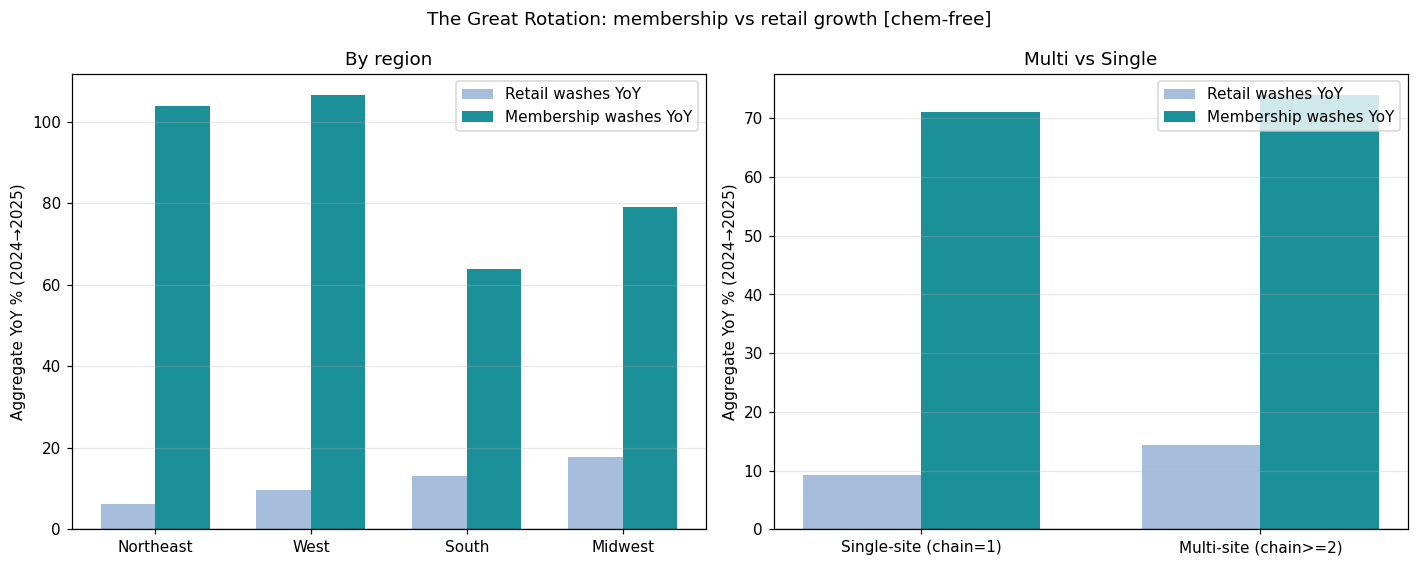

In [8]:
common = [
    'client_id_location_id', 'client_id', 'year_month_dt', 'region',
    'wash_count_retail', 'wash_count_membership', 'wash_count_total',
]
panel = pd.concat([new[common], old[common]], ignore_index=True)
chain = (
    panel[['client_id', 'client_id_location_id']].drop_duplicates()
    .groupby('client_id').size().rename('chain_size')
)
panel = panel.merge(chain, on='client_id', how='left')
panel['is_multi'] = panel['chain_size'] > 1
panel['yr'] = panel['year_month_dt'].dt.year

annn = panel.groupby(['client_id_location_id', 'is_multi', 'region', 'yr'])[
    ['wash_count_retail', 'wash_count_membership']
].sum().reset_index()
pr = annn.pivot_table(index=['client_id_location_id', 'is_multi', 'region'], columns='yr', values='wash_count_retail').rename(columns=lambda c: f'r_{c}').reset_index()
pm = annn.pivot_table(index=['client_id_location_id', 'is_multi', 'region'], columns='yr', values='wash_count_membership').rename(columns=lambda c: f'm_{c}').reset_index()
rot = pr.merge(pm, on=['client_id_location_id', 'is_multi', 'region']).dropna()

def agg_yoy(frame, a, b):
    return (frame[b].sum() / frame[a].sum() - 1) * 100

reg = rot.groupby('region').apply(
    lambda f: pd.Series({'retail': agg_yoy(f, 'r_2024', 'r_2025'), 'membership': agg_yoy(f, 'm_2024', 'm_2025')})
).reindex(['Northeast', 'West', 'South', 'Midwest'])
ms = rot.groupby('is_multi').apply(
    lambda f: pd.Series({'retail': agg_yoy(f, 'r_2024', 'r_2025'), 'membership': agg_yoy(f, 'm_2024', 'm_2025')})
)
ms.index = ['Single-site (chain=1)' if not i else 'Multi-site (chain>=2)' for i in ms.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
x = np.arange(len(reg)); w = 0.35
axes[0].bar(x - w/2, reg['retail'], w, label='Retail washes YoY', color='#a6bddb')
axes[0].bar(x + w/2, reg['membership'], w, label='Membership washes YoY', color='#1c9099')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(reg.index)
axes[0].set_ylabel('Aggregate YoY % (2024→2025)')
axes[0].set_title('By region')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

x = np.arange(len(ms))
axes[1].bar(x - w/2, ms['retail'], w, label='Retail washes YoY', color='#a6bddb')
axes[1].bar(x + w/2, ms['membership'], w, label='Membership washes YoY', color='#1c9099')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(ms.index)
axes[1].set_ylabel('Aggregate YoY % (2024→2025)')
axes[1].set_title('Multi vs Single')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

fig.suptitle('The Great Rotation: membership vs retail growth [chem-free]', fontsize=12)
fig.tight_layout()
plt.show()

# N-body interaction diagrams — 2-body, 3-body, and overall

Self-contained: uses only the two no-chem CSVs at the given paths and their native columns (`calendar_year`, `calendar_month`, `client_type`, `client_id`, `latitude`, `longitude`, `zip`, `operational_start_date`, `wash_count_total`). No legacy schema, no temp files.

Method (mirrors `site_interaction_analysis_lib` but inline):
- A **pair** = (new site N, existing site E): E launched ≥ 6 months before N, distance ≤ 10 mi, same-zip preferred else nearest within radius.
- A **triple** = (A, B, C) where C is the newest, A & B are older neighbors of C within 10 mi with ≥ 6-month launch gap between them, same-zip preferred.
- For each event (newest site's launch month), compute pre/post 6-month means for each older site and build an event-time trace indexed to the older site(s)' pre-launch mean = 100.

In [9]:
# --- Build a single panel from `new` and `old` (native columns only) ---
def to_panel(df, cohort_label):
    out = df[['client_id_location_id', 'client_id', 'operational_start_date',
              'latitude', 'longitude', 'zip', 'state', 'region',
              'wash_count_retail', 'wash_count_membership', 'wash_count_total',
              'year_month_dt']].copy()
    out['client_type'] = df['client_type'] if 'client_type' in df.columns else np.nan
    out['cohort'] = cohort_label
    return out

intpanel = pd.concat([to_panel(new, 'lt2'), to_panel(old, 'gt2')], ignore_index=True)
intpanel['launch_month']   = pd.to_datetime(intpanel['operational_start_date'], errors='coerce').dt.to_period('M').dt.to_timestamp()
intpanel['calendar_month'] = intpanel['year_month_dt'].dt.to_period('M').dt.to_timestamp()

# Prefer lt2 row when the same site-month appears in both files
intpanel = (intpanel.sort_values(['client_id_location_id', 'calendar_month', 'cohort'])
                    .drop_duplicates(['client_id_location_id', 'calendar_month'], keep='first')
                    .reset_index(drop=True))

# Fill client_type: lt2-known location → infer from chain size for GT2Y-only sites
known = (intpanel.dropna(subset=['client_type'])
                 .drop_duplicates('client_id_location_id')
                 .set_index('client_id_location_id')['client_type'])
intpanel['client_type'] = intpanel['client_type'].fillna(intpanel['client_id_location_id'].map(known))
chain = intpanel[['client_id', 'client_id_location_id']].drop_duplicates().groupby('client_id').size()
intpanel['client_type'] = intpanel['client_type'].fillna(
    intpanel['client_id'].map(chain.apply(lambda n: 'single_site' if n == 1 else 'multi_site'))
)

def type_label(ct):
    if pd.isna(ct): return 'unknown'
    s = str(ct).strip().lower()
    if s in ('single_site', 'single'): return 'single'
    if s in ('multi_site',  'multi'):  return 'multi'
    return s

site_type = (intpanel.dropna(subset=['client_type'])
                     .drop_duplicates('client_id_location_id')
                     .set_index('client_id_location_id')['client_type']
                     .map(type_label))

print(f'intpanel: {len(intpanel):,} rows  |  {intpanel["client_id_location_id"].nunique():,} sites')

intpanel: 15,241 rows  |  700 sites


In [10]:
# --- Site table + pairwise distance matrix (miles) ---
sites = (intpanel.dropna(subset=['latitude', 'longitude'])
                 .groupby('client_id_location_id')
                 .agg(client_id=('client_id', 'first'),
                      launch_month=('launch_month', 'min'),
                      lat=('latitude', 'first'), lon=('longitude', 'first'),
                      zip=('zip', 'first'), state=('state', 'first'),
                      region=('region', 'first'),
                      client_type=('client_type', 'first'),
                      cohort=('cohort', 'first'))
                 .reset_index()
                 .sort_values('client_id_location_id').reset_index(drop=True))
sites['has_launch'] = sites['launch_month'].notna()

def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.7613
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

_c = sites[['lat', 'lon']].to_numpy(float)
D = haversine_miles(_c[:, 0:1], _c[:, 1:2], _c[:, 0:1].T, _c[:, 1:2].T)

MAX_MI = 10.0
WINDOW = 6   # pre/post window (months)
MIN_GAP = 6  # min launch-month gap between paired sites

print(f'sites: {len(sites):,}  |  distance matrix: {D.shape}')

sites: 698  |  distance matrix: (698, 698)


In [11]:
# --- Find pairs (newest N + one older E within MAX_MI, same-zip preferred) ---
def month_diff(later, earlier):
    return (later.year - earlier.year) * 12 + (later.month - earlier.month)

pairs = []
for i, n_row in sites.iterrows():
    if not n_row['has_launch']: continue
    cutoff = n_row['launch_month'] - pd.DateOffset(months=MIN_GAP)
    cand = sites[(sites.index != i) & sites['has_launch'] & (sites['launch_month'] <= cutoff)].copy()
    if cand.empty: continue
    cand['dist'] = D[i, cand.index]
    cand = cand[cand['dist'] <= MAX_MI].sort_values(['dist', 'launch_month'])
    if cand.empty: continue
    same_zip = cand[cand['zip'] == n_row['zip']]
    pool = same_zip if not same_zip.empty else cand
    e = pool.iloc[0]
    pairs.append({'new_site': n_row['client_id_location_id'],
                  'existing_site': e['client_id_location_id'],
                  'new_launch_month': n_row['launch_month'],
                  'distance_miles': float(e['dist']),
                  'state': n_row['state'], 'region': n_row['region']})
pairs_df = pd.DataFrame(pairs)

# --- Find triples (newest C + two older A,B; same-zip preferred) ---
triples = []
for i, c_row in sites.iterrows():
    if not c_row['has_launch']: continue
    older = sites[(sites.index != i) & sites['has_launch']
                  & (sites['launch_month'] <= c_row['launch_month'] - pd.DateOffset(months=MIN_GAP))].copy()
    if len(older) < 2: continue
    older['dist'] = D[i, older.index]
    older = older[older['dist'] <= MAX_MI]
    if len(older) < 2: continue
    same_zip = older[older['zip'] == c_row['zip']]
    pool = (same_zip if len(same_zip) >= 2 else older).sort_values(['dist', 'launch_month']).reset_index(drop=True)
    best = None
    for l in range(len(pool)):
        for r in range(l + 1, len(pool)):
            s1, s2 = pool.iloc[l], pool.iloc[r]
            if abs(month_diff(s2['launch_month'], s1['launch_month'])) < MIN_GAP: continue
            a, b = sorted([s1, s2], key=lambda s: s['launch_month'])
            score = (a['dist'] + b['dist'], max(a['dist'], b['dist']))
            if best is None or score < best[0]:
                best = (score, a, b)
    if best is None: continue
    _, a, b = best
    triples.append({'A_site': a['client_id_location_id'],
                    'B_site': b['client_id_location_id'],
                    'C_site': c_row['client_id_location_id'],
                    'C_launch': c_row['launch_month'],
                    'A_to_C_mi': float(a['dist']), 'B_to_C_mi': float(b['dist'])})
triples_df = pd.DataFrame(triples)

print(f'pairs: {len(pairs_df):,}   triples: {len(triples_df):,}')

pairs: 256   triples: 94


In [12]:
# --- Per-site monthly series for fast event-time lookups ---
site_series = {sid: g.set_index('calendar_month')['wash_count_total'].sort_index()
               for sid, g in intpanel.groupby('client_id_location_id')}

def window_mean(sid, event_month, side, months=WINDOW):
    s = site_series.get(sid)
    if s is None or s.empty: return np.nan, 0
    if side == 'pre':
        m = (s.index < event_month) & (s.index >= event_month - pd.DateOffset(months=months))
    else:
        m = (s.index >= event_month) & (s.index < event_month + pd.DateOffset(months=months))
    w = s[m]
    return (w.mean() if len(w) else np.nan), int(len(w))

def site_value_at(sid, event_month, rel):
    s = site_series.get(sid)
    if s is None: return np.nan
    target = event_month + pd.DateOffset(months=int(rel))
    return float(s.loc[target]) if target in s.index else np.nan

# Pair event-time traces (indexed to existing site's pre-launch mean = 100)
pt = []
for _, p in pairs_df.iterrows():
    ev = p['new_launch_month']
    base, n_pre  = window_mean(p['existing_site'], ev, 'pre')
    _,    n_post = window_mean(p['existing_site'], ev, 'post')
    if pd.isna(base) or base <= 0 or n_pre < 3 or n_post < 3: continue
    et = site_type.get(p['existing_site'], 'unknown')
    nt = site_type.get(p['new_site'],      'unknown')
    for rel in range(-WINDOW, WINDOW + 1):
        ex = site_value_at(p['existing_site'], ev, rel)
        nw = site_value_at(p['new_site'],      ev, rel) if rel >= 0 else np.nan
        comb = (ex if pd.notna(ex) else 0) + (nw if pd.notna(nw) else 0)
        pt.append({'pair_id': f"{p['existing_site']}->{p['new_site']}", 'rel': rel,
                   'existing_idx': ex / base * 100 if pd.notna(ex) else np.nan,
                   'new_idx':      nw / base * 100 if pd.notna(nw) else np.nan,
                   'combined_idx': comb / base * 100 if (pd.notna(ex) or pd.notna(nw)) else np.nan,
                   'existing_type': et, 'new_type': nt})
pair_traces = pd.DataFrame(pt)

# Triple event-time traces (aligned to C; base = A_pre + B_pre)
tt = []
for _, t in triples_df.iterrows():
    ev = t['C_launch']
    a_pre, na_pre   = window_mean(t['A_site'], ev, 'pre')
    b_pre, nb_pre   = window_mean(t['B_site'], ev, 'pre')
    _,     na_post  = window_mean(t['A_site'], ev, 'post')
    _,     nb_post  = window_mean(t['B_site'], ev, 'post')
    if pd.isna(a_pre) or pd.isna(b_pre) or min(na_pre, nb_pre, na_post, nb_post) < 3: continue
    base = a_pre + b_pre
    if base <= 0: continue
    c_type = site_type.get(t['C_site'], 'unknown')
    for rel in range(-WINDOW, WINDOW + 1):
        a = site_value_at(t['A_site'], ev, rel)
        b = site_value_at(t['B_site'], ev, rel)
        c = site_value_at(t['C_site'], ev, rel) if rel >= 0 else np.nan
        any_val = pd.notna(a) or pd.notna(b) or pd.notna(c)
        region = (a if pd.notna(a) else 0) + (b if pd.notna(b) else 0) + (c if pd.notna(c) else 0)
        tt.append({'triple_id': f"{t['A_site']}|{t['B_site']}|{t['C_site']}", 'rel': rel,
                   'A_idx': a / base * 100 if pd.notna(a) else np.nan,
                   'B_idx': b / base * 100 if pd.notna(b) else np.nan,
                   'C_idx': c / base * 100 if pd.notna(c) else np.nan,
                   'region_idx': region / base * 100 if any_val else np.nan,
                   'C_type': c_type})
triple_traces = pd.DataFrame(tt)

print(f'valid pairs: {pair_traces["pair_id"].nunique():,}  |  valid triples: {triple_traces["triple_id"].nunique():,}')

valid pairs: 84  |  valid triples: 41


## 2-body — pair event-time trends

Left: existing-single × new-multi pairs (the headline cannibalization signature). Right: 2×2 grid of all (existing × new) site-type combinations.

Y-axis = wash index where the existing site's pre-launch 6-month mean = 100. Bold line = median across pairs; band = 25th–75th percentile.

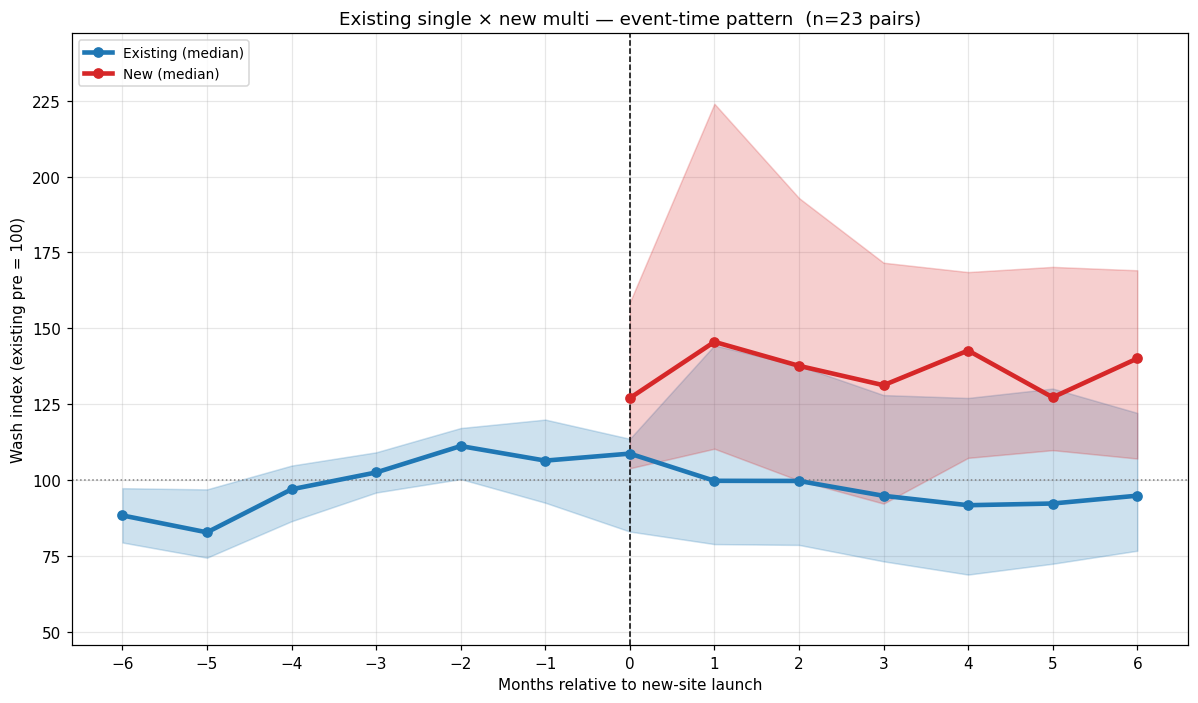

In [13]:
def _plot_pair_panel(ax, df, title, ylim=None):
    n = df['pair_id'].nunique()
    if n == 0:
        ax.text(0.5, 0.5, 'no pairs', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title); return None
    band_min, band_max = np.inf, -np.inf
    for col, color, label in [('existing_idx', '#1f77b4', 'Existing'),
                              ('new_idx',      '#d62728', 'New')]:
        summ = df.groupby('rel')[col].agg(med='median',
                                          q25=lambda s: s.quantile(0.25),
                                          q75=lambda s: s.quantile(0.75)).reset_index()
        ax.fill_between(summ['rel'], summ['q25'], summ['q75'], color=color, alpha=0.22, zorder=2)
        ax.plot(summ['rel'], summ['med'], color=color, lw=3.0, marker='o', ms=6,
                label=f'{label} (median)', zorder=3)
        band_min = min(band_min, float(np.nanmin(summ['q25'])))
        band_max = max(band_max, float(np.nanmax(summ['q75'])))
    ax.axvline(0, color='black', ls='--', lw=1)
    ax.axhline(100, color='gray', ls=':', lw=1)
    ax.set_xticks(range(-WINDOW, WINDOW + 1))
    ax.set_xlabel('Months relative to new-site launch')
    ax.set_ylabel('Wash index (existing pre = 100)')
    ax.set_title(f'{title}  (n={n} pairs)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    # Scale: tight margin around the IQR band so the median is readable
    if ylim is None:
        pad = max(10.0, (band_max - band_min) * 0.15)
        ylim = (max(0, band_min - pad), band_max + pad)
    ax.set_ylim(*ylim)
    return ylim

# --- 2-body: existing-single × new-multi (the headline cannibalization signature) ---
fig, ax = plt.subplots(figsize=(11, 6.5))
sub = pair_traces[(pair_traces['existing_type'] == 'single') & (pair_traces['new_type'] == 'multi')]
_plot_pair_panel(ax, sub, 'Existing single × new multi — event-time pattern')
fig.tight_layout()
plt.show()

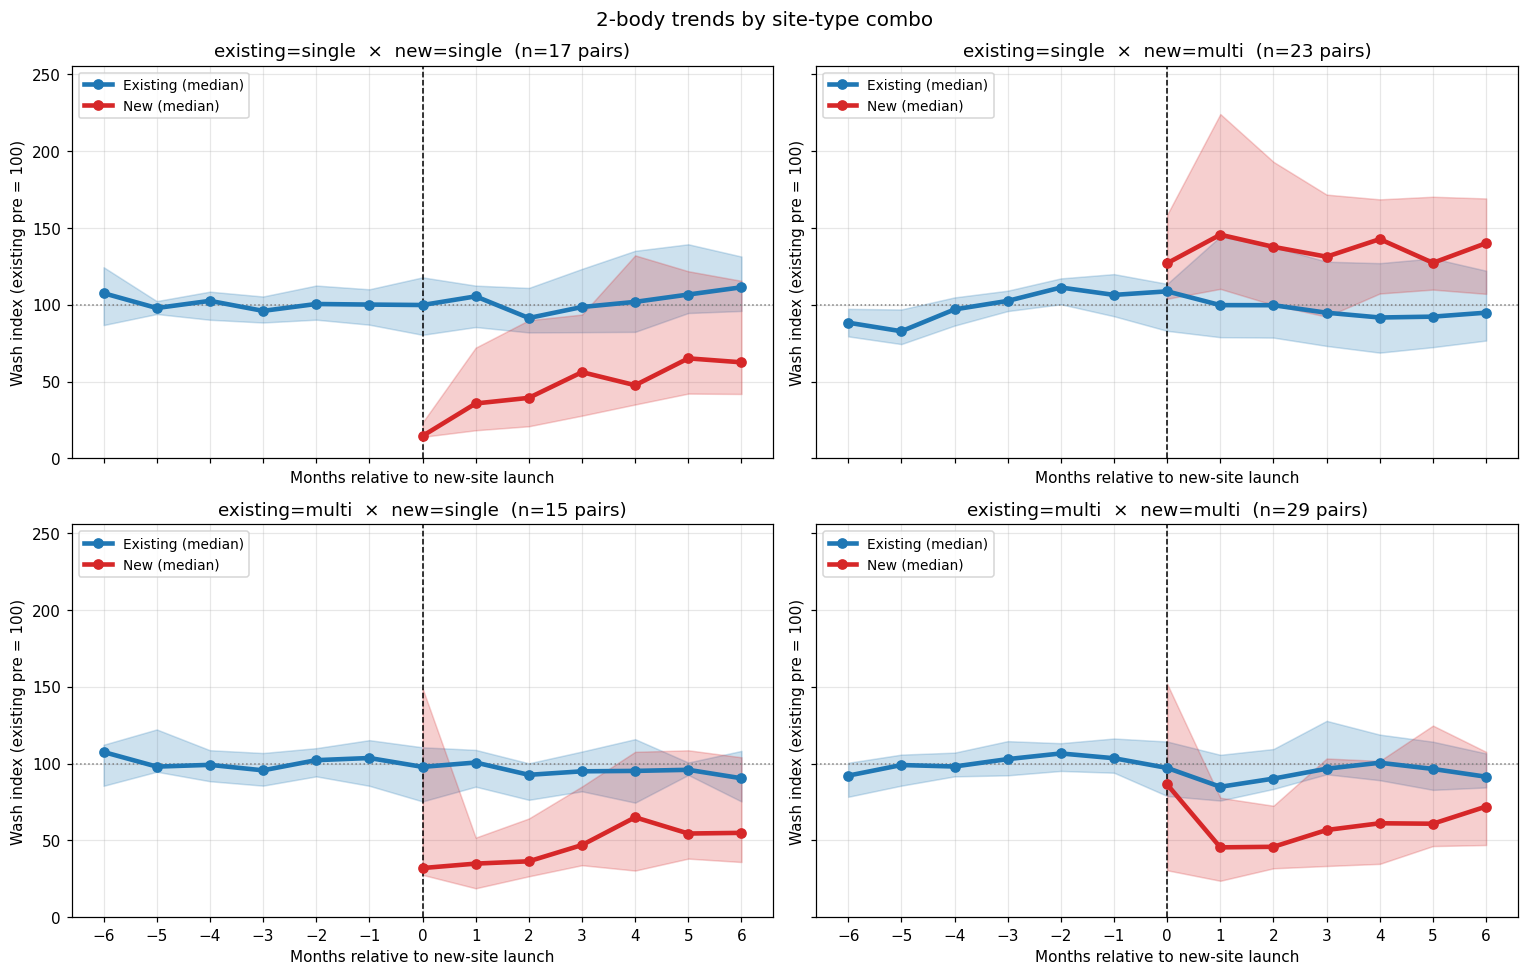

In [14]:
# --- 2-body: 2x2 grid of all (existing × new) site-type combos (shared y for fair comparison) ---
combos = [('single', 'single'), ('single', 'multi'),
          ('multi',  'single'), ('multi',  'multi')]

# First pass: compute a common y-range from the IQR envelopes across all panels
gmin, gmax = np.inf, -np.inf
for et, nt in combos:
    sub = pair_traces[(pair_traces['existing_type'] == et) & (pair_traces['new_type'] == nt)]
    if sub.empty: continue
    for col in ('existing_idx', 'new_idx'):
        summ = sub.groupby('rel')[col].agg(q25=lambda s: s.quantile(0.25),
                                           q75=lambda s: s.quantile(0.75))
        gmin = min(gmin, float(np.nanmin(summ['q25'])))
        gmax = max(gmax, float(np.nanmax(summ['q75'])))
pad = max(10.0, (gmax - gmin) * 0.15)
shared_ylim = (max(0, gmin - pad), gmax + pad)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for ax, (et, nt) in zip(axes.flat, combos):
    sub = pair_traces[(pair_traces['existing_type'] == et) & (pair_traces['new_type'] == nt)]
    _plot_pair_panel(ax, sub, f'existing={et}  ×  new={nt}', ylim=shared_ylim)
fig.suptitle('2-body trends by site-type combo', fontsize=13)
fig.tight_layout()
plt.show()

## All 2-body cases — small-multiples (with distance)

Every valid pair as its own panel, sorted by distance (ascending). Each panel: existing site (blue) and new site (red) wash index vs months relative to the new site's launch. Panel title shows distance (mi) and site-type combo (existing→new).


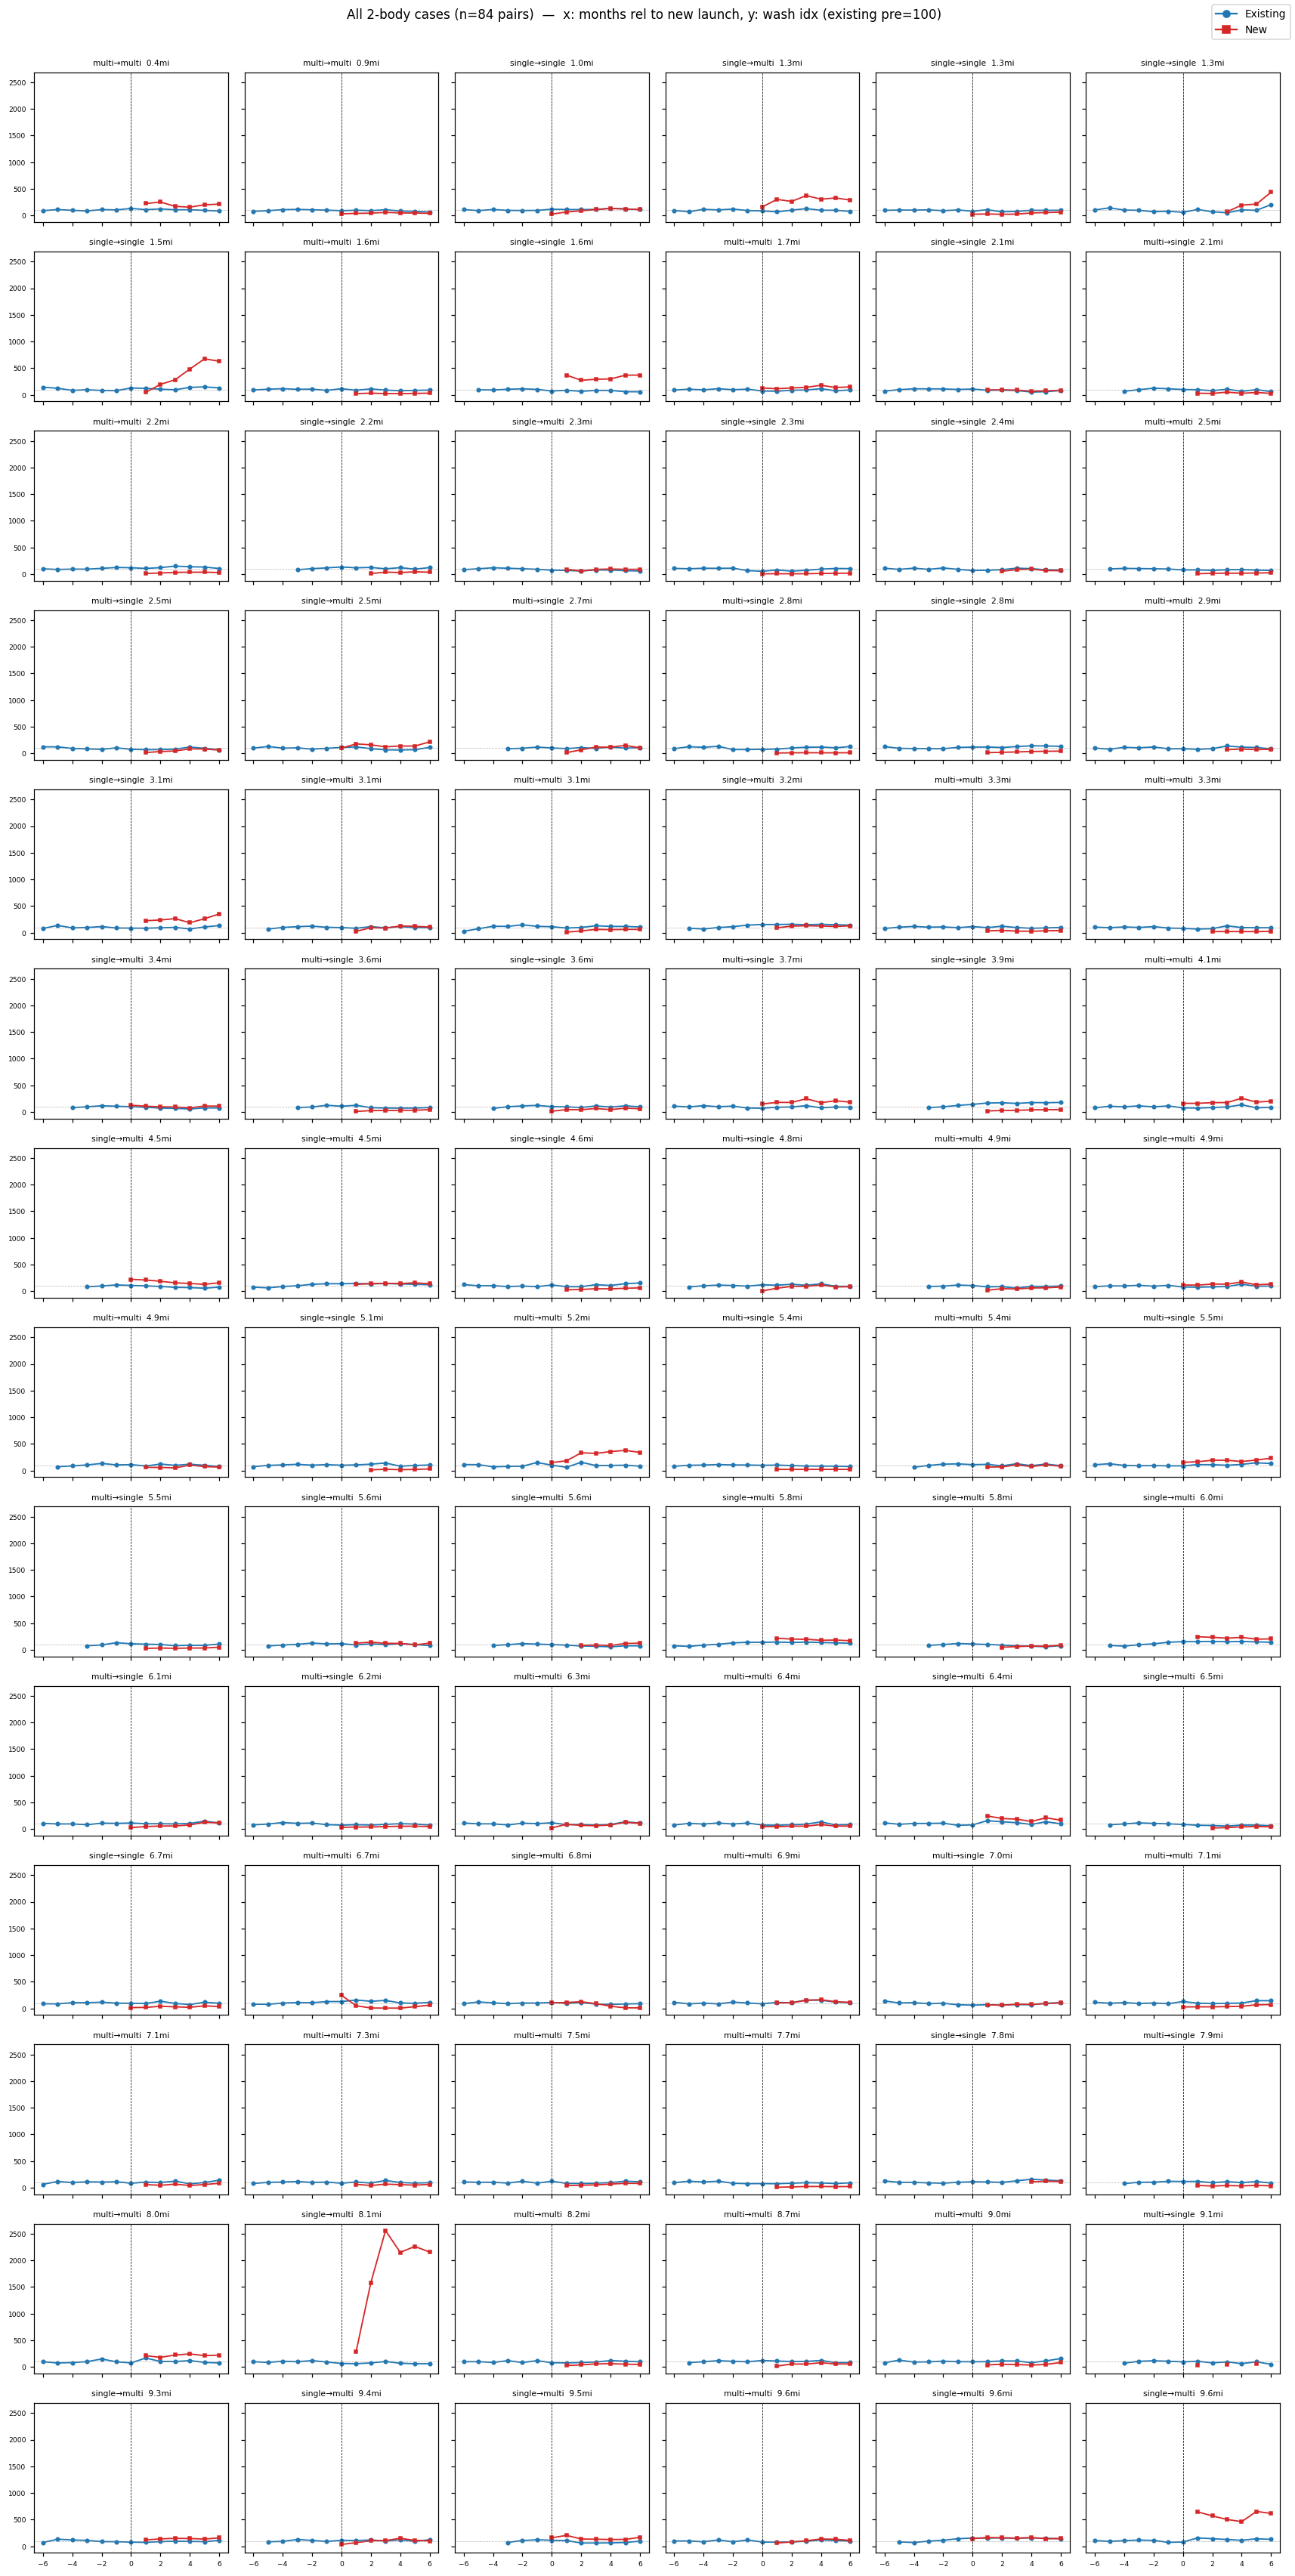

In [15]:
import math

pair_ids = list(pair_traces['pair_id'].unique())
n = len(pair_ids)

# Distance lookup keyed by pair_id
dist_lookup = {f"{r['existing_site']}->{r['new_site']}": r['distance_miles']
               for _, r in pairs_df.iterrows()}

pair_ids = sorted(pair_ids, key=lambda p: dist_lookup.get(p, 999))

ncols = 6
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2.6, nrows*2.2), sharey=True, sharex=True)
axes = np.atleast_2d(axes)
for ax in axes.flat:
    ax.set_visible(False)

for k, pid in enumerate(pair_ids):
    r, c = divmod(k, ncols)
    ax = axes[r, c]; ax.set_visible(True)
    sub = pair_traces[pair_traces['pair_id'] == pid].sort_values('rel')
    ax.plot(sub['rel'], sub['existing_idx'], 'o-', color='#1f77b4', ms=3, lw=1.2)
    ax.plot(sub['rel'], sub['new_idx'],      's-', color='#d62728', ms=3, lw=1.2)
    ax.axvline(0, color='black', ls='--', lw=0.5)
    ax.axhline(100, color='gray', ls=':', lw=0.5)
    et = sub['existing_type'].iloc[0]; nt = sub['new_type'].iloc[0]
    d  = dist_lookup.get(pid, np.nan)
    ax.set_title(f'{et}→{nt}  {d:.1f}mi', fontsize=7)
    ax.tick_params(labelsize=6)

# Single legend
from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([0],[0], color='#1f77b4', marker='o', label='Existing'),
                    Line2D([0],[0], color='#d62728', marker='s', label='New')],
           loc='upper right', fontsize=9)
fig.suptitle(f'All 2-body cases (n={n} pairs)  —  x: months rel to new launch, y: wash idx (existing pre=100)',
             fontsize=11, y=1.005)
fig.tight_layout()
plt.show()


## 2-body cumulative impact by site-type combo

Per pair: post-window mean minus pre-window mean of the existing-site wash index, and of the combined-market (existing+new) wash index. Aggregated as the median across pairs within each (existing-type × new-type) cell.


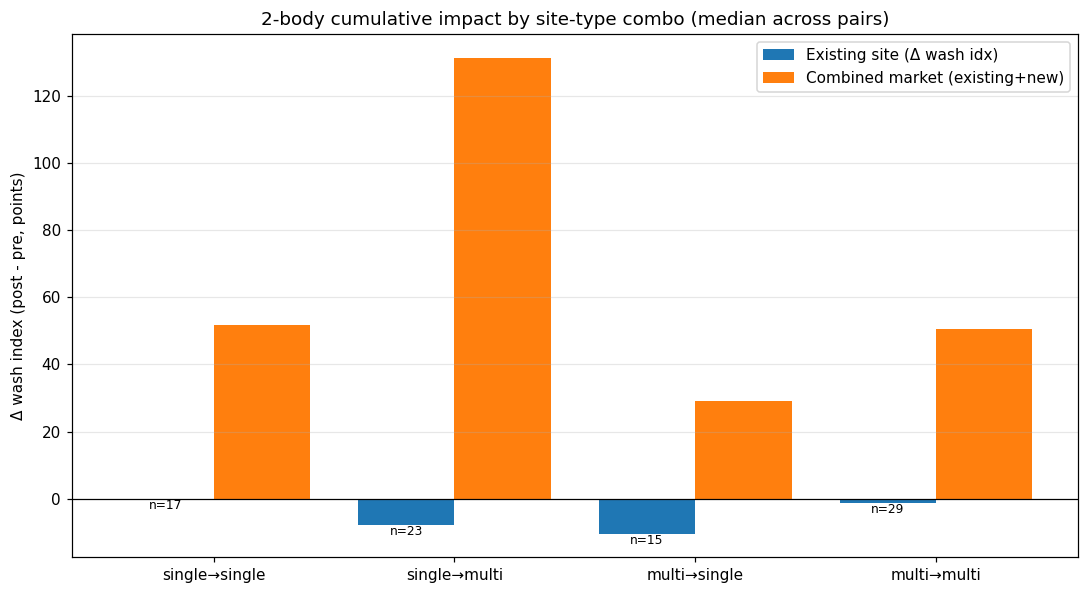

In [16]:
rows = []
for pid, sub in pair_traces.groupby('pair_id'):
    pre_e  = sub.loc[sub['rel'] <  0, 'existing_idx'].mean()
    post_e = sub.loc[sub['rel'] >= 0, 'existing_idx'].mean()
    pre_c  = sub.loc[sub['rel'] <  0, 'combined_idx'].mean()
    post_c = sub.loc[sub['rel'] >= 0, 'combined_idx'].mean()
    rows.append({'pair_id': pid,
                 'existing_type': sub['existing_type'].iloc[0],
                 'new_type':      sub['new_type'].iloc[0],
                 'd_existing': post_e - pre_e,
                 'd_combined': post_c - pre_c})
pair_agg = pd.DataFrame(rows).dropna(subset=['d_existing','d_combined'])

combos = [('single','single'), ('single','multi'), ('multi','single'), ('multi','multi')]
labels = [f'{e}→{n}' for e,n in combos]
ex_med, co_med, counts = [], [], []
for e,n in combos:
    sub = pair_agg[(pair_agg['existing_type']==e) & (pair_agg['new_type']==n)]
    ex_med.append(sub['d_existing'].median() if len(sub) else np.nan)
    co_med.append(sub['d_combined'].median() if len(sub) else np.nan)
    counts.append(len(sub))

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(combos)); w = 0.4
ax.bar(x - w/2, ex_med, w, color='#1f77b4', label='Existing site (Δ wash idx)')
ax.bar(x + w/2, co_med, w, color='#ff7f0e', label='Combined market (existing+new)')
ax.axhline(0, color='black', lw=0.8)
for i, (em, cm, nn) in enumerate(zip(ex_med, co_med, counts)):
    if not np.isnan(em):
        ax.text(i - w/2, em, f'n={nn}', ha='center',
                va='bottom' if em >= 0 else 'top', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Δ wash index (post - pre, points)')
ax.set_title('2-body cumulative impact by site-type combo (median across pairs)')
ax.legend(); ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
plt.show()


## 3-body — triple event-time trends

A & B are pre-existing neighbors of C (the newest entrant). Plots the median A, B, C and combined-market (A+B+C) indices around C's launch month. Indexed to A+B's pre-launch mean = 100.

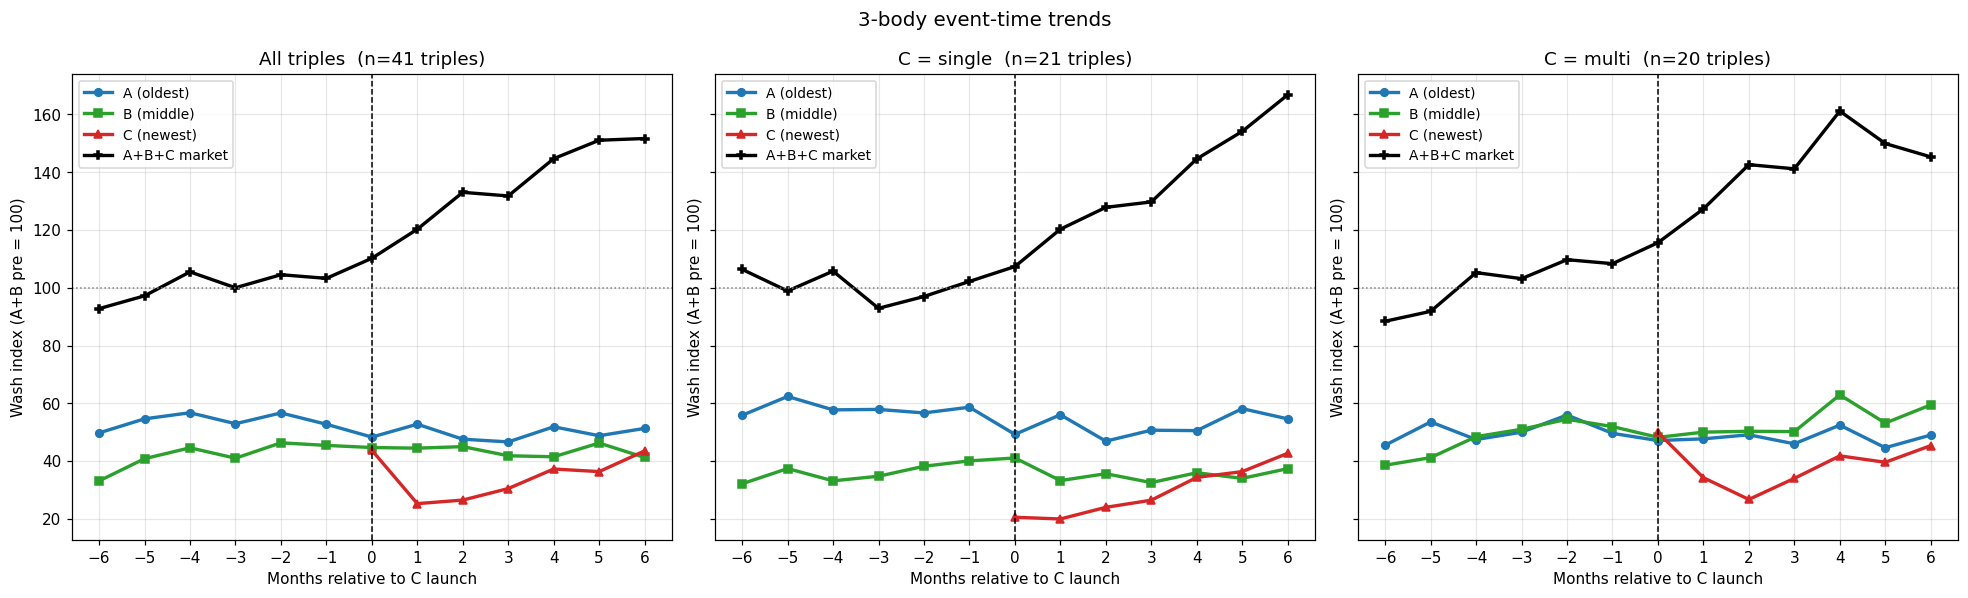

In [17]:
def _plot_triple_panel(ax, df, title):
    n = df['triple_id'].nunique()
    if n == 0:
        ax.text(0.5, 0.5, 'no triples', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title); return
    series = [('A_idx',      '#1f77b4', 'o', 'A (oldest)'),
              ('B_idx',      '#2ca02c', 's', 'B (middle)'),
              ('C_idx',      '#d62728', '^', 'C (newest)'),
              ('region_idx', '#000000', 'P', 'A+B+C market')]
    for col, color, marker, label in series:
        summ = df.groupby('rel')[col].median().reset_index()
        ax.plot(summ['rel'], summ[col], color=color, lw=2.2, marker=marker, ms=5, label=label)
    ax.axvline(0, color='black', ls='--', lw=1)
    ax.axhline(100, color='gray', ls=':', lw=1)
    ax.set_xticks(range(-WINDOW, WINDOW + 1))
    ax.set_xlabel('Months relative to C launch')
    ax.set_ylabel('Wash index (A+B pre = 100)')
    ax.set_title(f'{title}  (n={n} triples)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)

# Overall (all triples pooled) + split by C's site type
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
_plot_triple_panel(axes[0], triple_traces,                              'All triples')
_plot_triple_panel(axes[1], triple_traces[triple_traces['C_type'] == 'single'], 'C = single')
_plot_triple_panel(axes[2], triple_traces[triple_traces['C_type'] == 'multi'],  'C = multi')
fig.suptitle('3-body event-time trends', fontsize=13)
fig.tight_layout()
plt.show()

## All 3-body cases — small-multiples

Every valid triple as its own panel, sorted by mean A/B distance to C. Each panel: A (blue), B (green), C (red) wash index vs months relative to C's launch. Indexed to (A+B)_pre = 100.


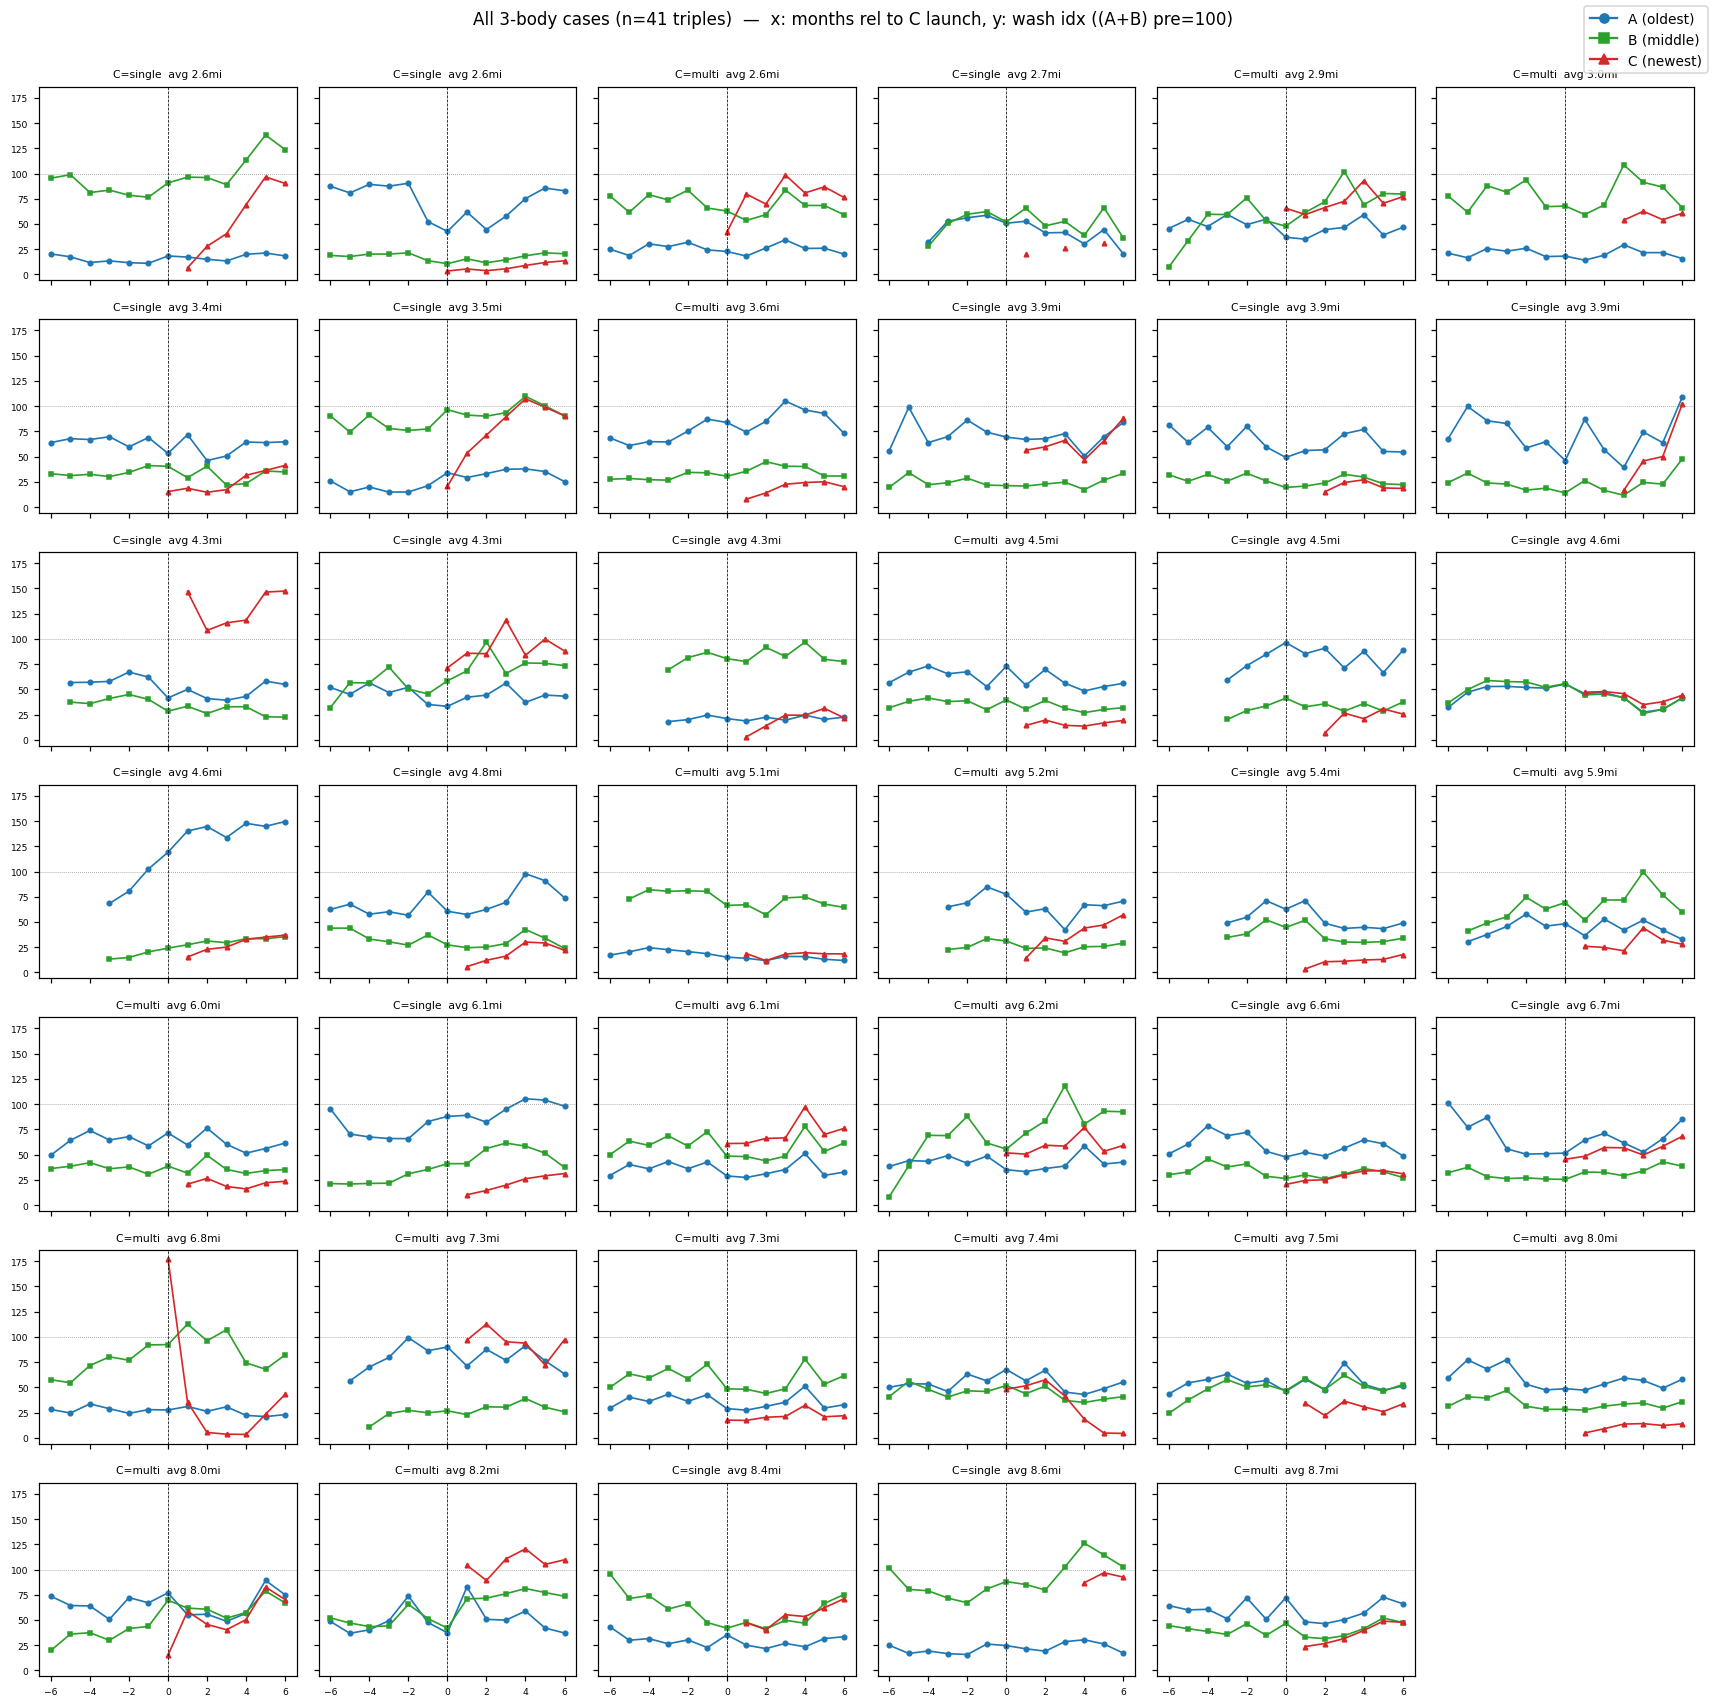

In [18]:
triple_ids = list(triple_traces['triple_id'].unique())
n = len(triple_ids)

dist_lookup3 = {f"{r['A_site']}|{r['B_site']}|{r['C_site']}": (r['A_to_C_mi'] + r['B_to_C_mi']) / 2
                for _, r in triples_df.iterrows()}
triple_ids = sorted(triple_ids, key=lambda p: dist_lookup3.get(p, 999))

ncols = 6
nrows = max(1, math.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2.6, nrows*2.2), sharey=True, sharex=True)
axes = np.atleast_2d(axes)
for ax in axes.flat:
    ax.set_visible(False)

for k, tid in enumerate(triple_ids):
    r, c = divmod(k, ncols)
    ax = axes[r, c]; ax.set_visible(True)
    sub = triple_traces[triple_traces['triple_id'] == tid].sort_values('rel')
    ax.plot(sub['rel'], sub['A_idx'], 'o-', color='#1f77b4', ms=3, lw=1.1)
    ax.plot(sub['rel'], sub['B_idx'], 's-', color='#2ca02c', ms=3, lw=1.1)
    ax.plot(sub['rel'], sub['C_idx'], '^-', color='#d62728', ms=3, lw=1.1)
    ax.axvline(0, color='black', ls='--', lw=0.5)
    ax.axhline(100, color='gray', ls=':', lw=0.5)
    ct = sub['C_type'].iloc[0]
    avg_d = dist_lookup3.get(tid, np.nan)
    ax.set_title(f'C={ct}  avg {avg_d:.1f}mi', fontsize=7)
    ax.tick_params(labelsize=6)

from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([0],[0], color='#1f77b4', marker='o', label='A (oldest)'),
                    Line2D([0],[0], color='#2ca02c', marker='s', label='B (middle)'),
                    Line2D([0],[0], color='#d62728', marker='^', label='C (newest)')],
           loc='upper right', fontsize=9)
fig.suptitle(f'All 3-body cases (n={n} triples)  —  x: months rel to C launch, y: wash idx ((A+B) pre=100)',
             fontsize=11, y=1.005)
fig.tight_layout()
plt.show()


## 3-body cumulative impact by C site type

Per triple: post minus pre window mean for each of A, B, C, and the combined market (A+B+C). Aggregated as the median across triples, split by C's site type.


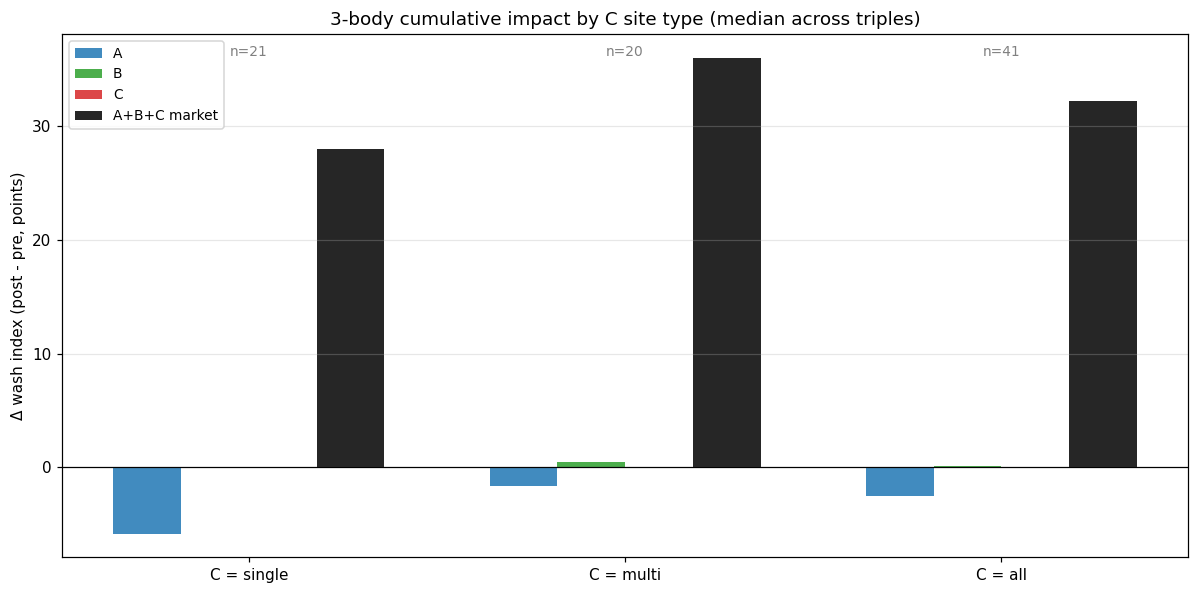

In [19]:
rows = []
for tid, sub in triple_traces.groupby('triple_id'):
    pre  = sub[sub['rel'] <  0]
    post = sub[sub['rel'] >= 0]
    rows.append({
        'triple_id': tid,
        'C_type': sub['C_type'].iloc[0],
        'd_A':      post['A_idx'].mean()      - pre['A_idx'].mean(),
        'd_B':      post['B_idx'].mean()      - pre['B_idx'].mean(),
        'd_C':      post['C_idx'].mean()      - pre['C_idx'].mean(),
        'd_region': post['region_idx'].mean() - pre['region_idx'].mean(),
    })
trip_agg = pd.DataFrame(rows)

groups = ['single', 'multi', 'all']

def med(g, col):
    sub = trip_agg if g == 'all' else trip_agg[trip_agg['C_type'] == g]
    return sub[col].median() if len(sub) else np.nan

def count(g):
    return len(trip_agg) if g == 'all' else int((trip_agg['C_type'] == g).sum())

metrics = [('d_A','A','#1f77b4'),
           ('d_B','B','#2ca02c'),
           ('d_C','C','#d62728'),
           ('d_region','A+B+C market','#000000')]

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(groups)); w = 0.18
for i, (col, lbl, color) in enumerate(metrics):
    vals = [med(g, col) for g in groups]
    ax.bar(x + (i - 1.5) * w, vals, w, color=color, label=lbl, alpha=0.85)

for j, g in enumerate(groups):
    ax.text(j, ax.get_ylim()[1] * 0.95, f'n={count(g)}', ha='center', fontsize=9, color='gray')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([f'C = {g}' for g in groups])
ax.set_ylabel('Δ wash index (post - pre, points)')
ax.set_title('3-body cumulative impact by C site type (median across triples)')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
plt.show()


## 4-body — quad event-time trends

A, B, C are pre-existing neighbors of D (the newest entrant). Each consecutive pair (A→B, B→C, C→D) is ≥ 6 months apart; all four sites are within 10 mi; same-zip preferred. Plots A/B/C/D and the combined-market (A+B+C+D) index around D's launch month, indexed to A+B+C's pre-launch mean = 100.

In [20]:
# --- Find quads (newest D + three older A,B,C; same-zip preferred) ---
quads = []
for i, d_row in sites.iterrows():
    if not d_row['has_launch']: continue
    older = sites[(sites.index != i) & sites['has_launch']
                  & (sites['launch_month'] <= d_row['launch_month'] - pd.DateOffset(months=MIN_GAP))].copy()
    if len(older) < 3: continue
    older['dist'] = D[i, older.index]
    older = older[older['dist'] <= MAX_MI]
    if len(older) < 3: continue
    same_zip = older[older['zip'] == d_row['zip']]
    pool = (same_zip if len(same_zip) >= 3 else older).sort_values(['dist', 'launch_month']).reset_index(drop=True)
    best = None
    n_pool = len(pool)
    for l in range(n_pool):
        for m in range(l + 1, n_pool):
            for r in range(m + 1, n_pool):
                s1, s2, s3 = pool.iloc[l], pool.iloc[m], pool.iloc[r]
                a, b, c = sorted([s1, s2, s3], key=lambda s: s['launch_month'])
                if abs(month_diff(b['launch_month'], a['launch_month'])) < MIN_GAP: continue
                if abs(month_diff(c['launch_month'], b['launch_month'])) < MIN_GAP: continue
                score = (a['dist'] + b['dist'] + c['dist'], max(a['dist'], b['dist'], c['dist']))
                if best is None or score < best[0]:
                    best = (score, a, b, c)
    if best is None: continue
    _, a, b, c = best
    quads.append({'A_site': a['client_id_location_id'],
                  'B_site': b['client_id_location_id'],
                  'C_site': c['client_id_location_id'],
                  'D_site': d_row['client_id_location_id'],
                  'D_launch': d_row['launch_month'],
                  'A_to_D_mi': float(a['dist']), 'B_to_D_mi': float(b['dist']), 'C_to_D_mi': float(c['dist'])})
quads_df = pd.DataFrame(quads)

# --- Quad event-time traces (aligned to D; base = A_pre + B_pre + C_pre) ---
qt = []
for _, q in quads_df.iterrows():
    ev = q['D_launch']
    pre_vals, n_pre_min, n_post_min = {}, np.inf, np.inf
    skip = False
    for role in ('A', 'B', 'C'):
        pr, n_pr = window_mean(q[f'{role}_site'], ev, 'pre')
        _,  n_po = window_mean(q[f'{role}_site'], ev, 'post')
        if pd.isna(pr): skip = True; break
        pre_vals[role] = pr
        n_pre_min = min(n_pre_min, n_pr); n_post_min = min(n_post_min, n_po)
    if skip or n_pre_min < 3 or n_post_min < 3: continue
    base = pre_vals['A'] + pre_vals['B'] + pre_vals['C']
    if base <= 0: continue
    d_type = site_type.get(q['D_site'], 'unknown')
    for rel in range(-WINDOW, WINDOW + 1):
        a = site_value_at(q['A_site'], ev, rel)
        b = site_value_at(q['B_site'], ev, rel)
        c = site_value_at(q['C_site'], ev, rel)
        d = site_value_at(q['D_site'], ev, rel) if rel >= 0 else np.nan
        any_val = any(pd.notna(x) for x in (a, b, c, d))
        region = sum((x if pd.notna(x) else 0) for x in (a, b, c, d))
        qt.append({'quad_id': f"{q['A_site']}|{q['B_site']}|{q['C_site']}|{q['D_site']}", 'rel': rel,
                   'A_idx': a / base * 100 if pd.notna(a) else np.nan,
                   'B_idx': b / base * 100 if pd.notna(b) else np.nan,
                   'C_idx': c / base * 100 if pd.notna(c) else np.nan,
                   'D_idx': d / base * 100 if pd.notna(d) else np.nan,
                   'region_idx': region / base * 100 if any_val else np.nan,
                   'D_type': d_type})
quad_traces = pd.DataFrame(qt)
print(f'quads: {len(quads_df):,}   valid quads: {quad_traces["quad_id"].nunique() if not quad_traces.empty else 0:,}')

quads: 36   valid quads: 23


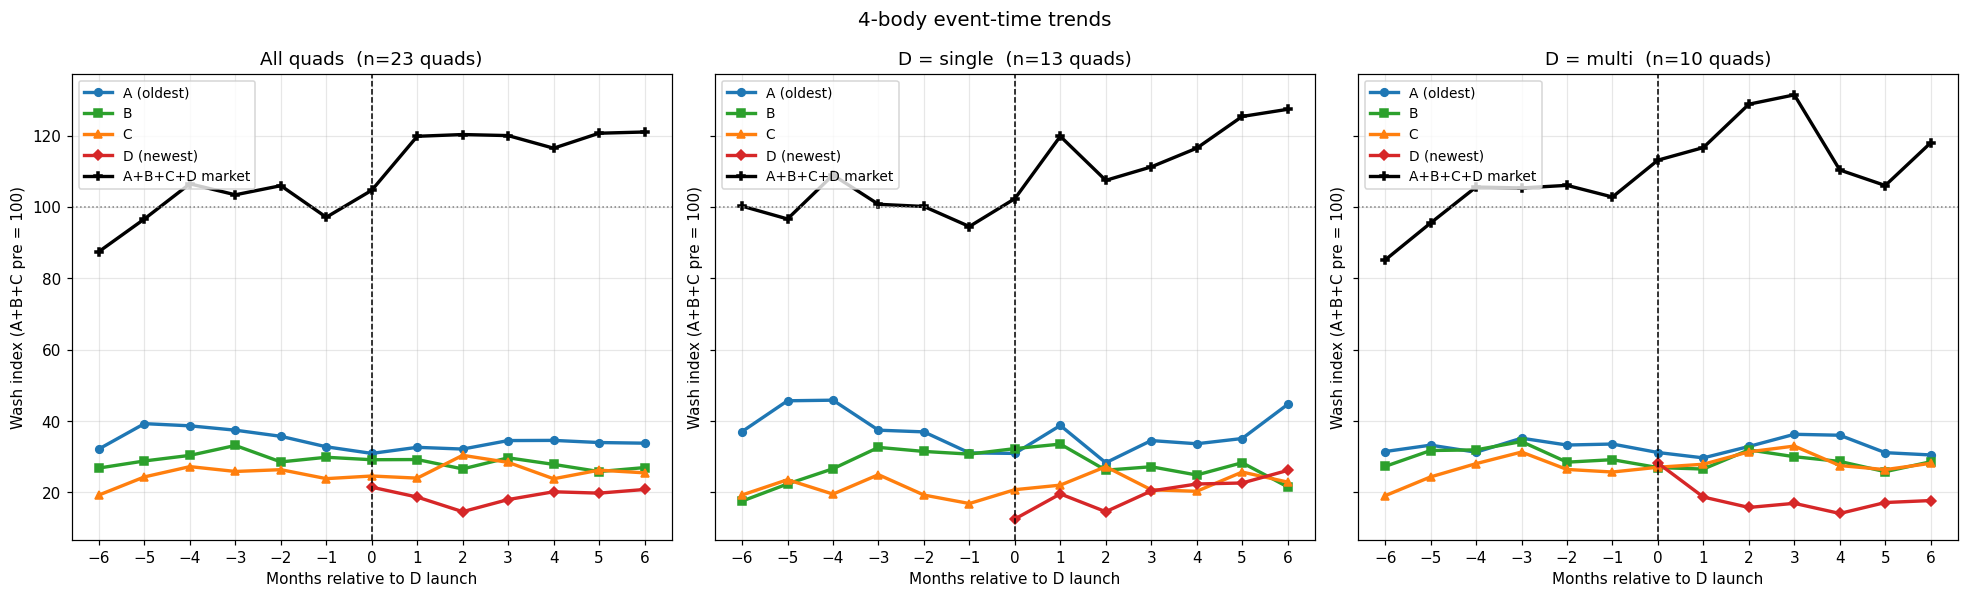

In [21]:
def _plot_quad_panel(ax, df, title):
    n = df['quad_id'].nunique() if not df.empty else 0
    if n == 0:
        ax.text(0.5, 0.5, 'no quads', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title); return
    series = [('A_idx',      '#1f77b4', 'o', 'A (oldest)'),
              ('B_idx',      '#2ca02c', 's', 'B'),
              ('C_idx',      '#ff7f0e', '^', 'C'),
              ('D_idx',      '#d62728', 'D', 'D (newest)'),
              ('region_idx', '#000000', 'P', 'A+B+C+D market')]
    for col, color, marker, label in series:
        summ = df.groupby('rel')[col].median().reset_index()
        ax.plot(summ['rel'], summ[col], color=color, lw=2.2, marker=marker, ms=5, label=label)
    ax.axvline(0, color='black', ls='--', lw=1)
    ax.axhline(100, color='gray', ls=':', lw=1)
    ax.set_xticks(range(-WINDOW, WINDOW + 1))
    ax.set_xlabel('Months relative to D launch')
    ax.set_ylabel('Wash index (A+B+C pre = 100)')
    ax.set_title(f'{title}  (n={n} quads)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)

# Overall + split by D's site type
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
_plot_quad_panel(axes[0], quad_traces,                                       'All quads')
_plot_quad_panel(axes[1], quad_traces[quad_traces['D_type'] == 'single'] if not quad_traces.empty else quad_traces, 'D = single')
_plot_quad_panel(axes[2], quad_traces[quad_traces['D_type'] == 'multi']  if not quad_traces.empty else quad_traces, 'D = multi')
fig.suptitle('4-body event-time trends', fontsize=13)
fig.tight_layout()
plt.show()

## Overall — any-new-operator effect & market-saturation threshold

**Left:** the pooled 2-body event-time effect across all pairs (regardless of site type) — the median existing-site index dipping below 100 around month 0 is the cannibalization signature; the combined-market line shows whether the new site recovers the lost volume.

**Right:** market-saturation curve — for each pair, the existing-site's post/pre % change vs how many other car washes were already in its zip at the time of the new launch.

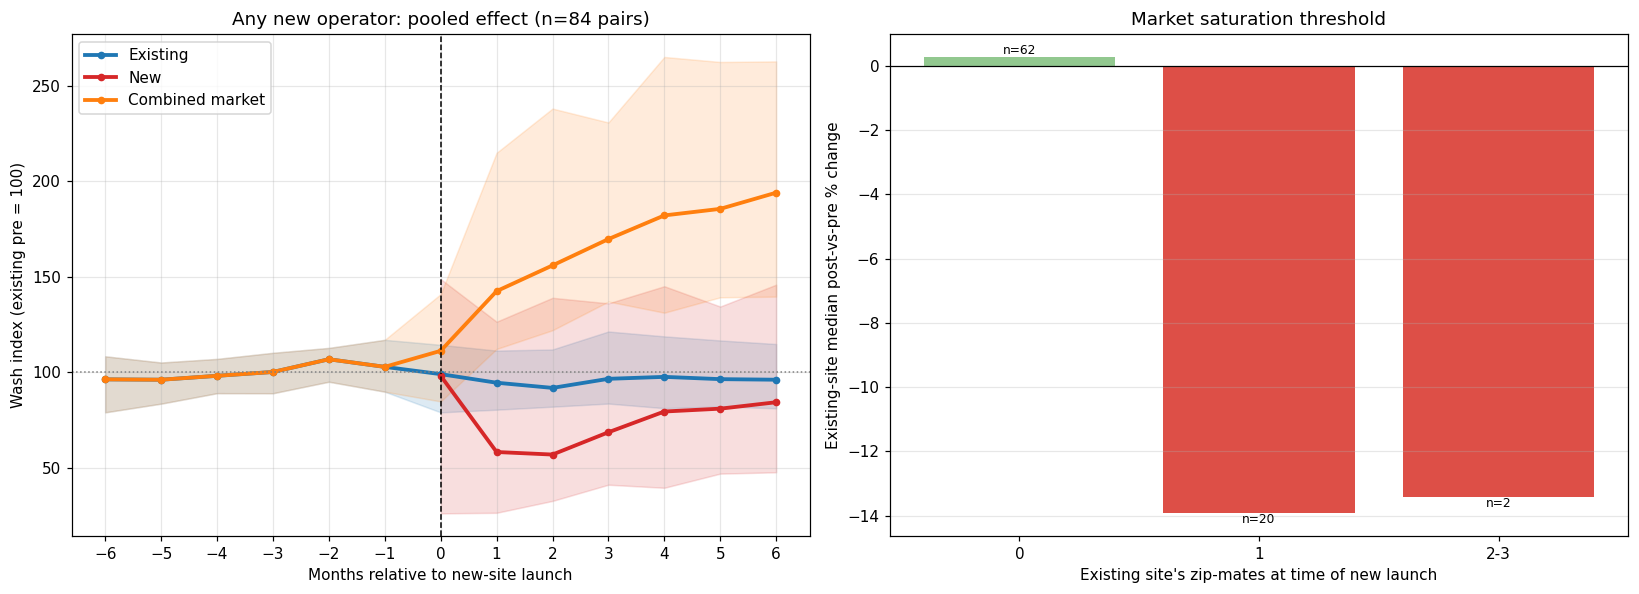

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- Aggregate any-new-operator effect (pooled pairs) ---
ax = axes[0]
n = pair_traces['pair_id'].nunique()
for col, color, label in [('existing_idx', '#1f77b4', 'Existing'),
                          ('new_idx',      '#d62728', 'New'),
                          ('combined_idx', '#ff7f0e', 'Combined market')]:
    summ = pair_traces.groupby('rel')[col].agg(med='median',
                                                q25=lambda s: s.quantile(0.25),
                                                q75=lambda s: s.quantile(0.75)).reset_index()
    ax.fill_between(summ['rel'], summ['q25'], summ['q75'], color=color, alpha=0.15)
    ax.plot(summ['rel'], summ['med'], color=color, lw=2.5, marker='o', ms=4, label=label)
ax.axvline(0, color='black', ls='--', lw=1)
ax.axhline(100, color='gray', ls=':', lw=1)
ax.set_xticks(range(-WINDOW, WINDOW + 1))
ax.set_xlabel('Months relative to new-site launch')
ax.set_ylabel('Wash index (existing pre = 100)')
ax.set_title(f'Any new operator: pooled effect (n={n} pairs)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# --- Market saturation: existing post/pre vs zip-mate count at launch ---
ax = axes[1]
zips_per_site = sites.set_index('client_id_location_id')['zip']
zip_counts = zips_per_site.value_counts()

pair_summary = []
for _, p in pairs_df.iterrows():
    ev = p['new_launch_month']
    pre,  n_pre  = window_mean(p['existing_site'], ev, 'pre')
    post, n_post = window_mean(p['existing_site'], ev, 'post')
    if pd.isna(pre) or pre <= 0 or pd.isna(post) or n_pre < 3 or n_post < 3: continue
    z = zips_per_site.get(p['existing_site'])
    if pd.isna(z): continue
    pct = (post - pre) / pre * 100
    pair_summary.append({'zip_peers': int(zip_counts.get(z, 1) - 1), 'pct': pct})
psum = pd.DataFrame(pair_summary)

if not psum.empty:
    psum['bucket'] = pd.cut(psum['zip_peers'], bins=[-0.5, 0.5, 1.5, 3.5, 6.5, 999],
                            labels=['0', '1', '2-3', '4-6', '7+'])
    g = psum.groupby('bucket').agg(median_pct=('pct', 'median'),
                                    pct_decline=('pct', lambda s: (s < 0).mean() * 100),
                                    n=('pct', 'size')).reset_index()
    colors = ['#7fbf7b' if v >= 0 else '#d73027' for v in g['median_pct'].fillna(0)]
    ax.bar(g['bucket'].astype(str), g['median_pct'], color=colors, alpha=0.85)
    for i, row in g.iterrows():
        ax.text(i, row['median_pct'], f'n={row["n"]}', ha='center',
                va='bottom' if row['median_pct'] >= 0 else 'top', fontsize=8)
    ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Existing site\'s zip-mates at time of new launch')
ax.set_ylabel('Existing-site median post-vs-pre % change')
ax.set_title('Market saturation threshold')
ax.grid(alpha=0.3, axis='y')

fig.tight_layout()
plt.show()